<a href="https://colab.research.google.com/github/AnnaShtyn/Final-Project/blob/main/%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B2_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Для дослідження датасету, побудови зведених таблиць, аналітичних графіків використаємо: *Pandas*,  та бібліотеки візуалізацій (*Matplotlib, Seaborn, Plotly*).

In [10]:
import pandas as pd

# Зчитаємо оригінальний набір даних у датафрейм, виведемо описову інформацію про нього
df = pd.read_csv('hotel_bookings_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119209 entries, 0 to 119208
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119209 non-null  object 
 1   is_canceled                     119209 non-null  int64  
 2   lead_time                       119209 non-null  float64
 3   arrival_date_year               119209 non-null  int64  
 4   arrival_date_month              119209 non-null  object 
 5   arrival_date_week_number        119209 non-null  int64  
 6   arrival_date_day_of_month       119209 non-null  int64  
 7   stays_in_weekend_nights         119209 non-null  int64  
 8   stays_in_week_nights            119209 non-null  int64  
 9   adults                          119209 non-null  int64  
 10  children                        119209 non-null  float64
 11  babies                          119209 non-null  int64  
 12  country         

In [11]:
# Для зручності в подальшій роботі створимо модифікований датафрейм, де в нас не буде скасованих броней (лише реальні заселення)
df_actual_bookings = df[df['is_canceled'] == 0]

# Згрупуємо дані фактичного заїзду в готель у зведену таблицю за роком, місяцем для аналізу динаміки, врахувавши лише не відмінені броні (в розрізі кожного готелю)
monthly_arrivals_by_hotel_pivot = df_actual_bookings.pivot_table(index= ['arrival_date_year', 'arrival_date_month'],
                                                 columns= 'hotel',
                                                 aggfunc='size'
                                                 )
# Також для порівняння з заповненістю готелів, визначимо середню величину ADR (ціни номера за  1 ночівлю) у зведеній таблиці теж помісячно
monthly_mean_adr_by_hotel_pivot = df.pivot_table(index= ['arrival_date_year', 'arrival_date_month'],
                                                 columns= 'hotel',
                                                 values='average_daily_rate',
                                                 aggfunc='mean'
                                                 )

# Оскільки pivot_table формуються з неправильним порядком місяців (в алф. порядку), виправимо, щоб було хронологічно вірно як у оригінальному датасеті
unique_year_months = df[['arrival_date_year', 'arrival_date_month']].drop_duplicates(keep='first')
monthly_arrivals_by_hotel_pivot = monthly_arrivals_by_hotel_pivot.reindex(pd.MultiIndex.from_frame(unique_year_months))
monthly_mean_adr_by_hotel_pivot = monthly_mean_adr_by_hotel_pivot.reindex(pd.MultiIndex.from_frame(unique_year_months))

# Виводимо 2 таблиці
display(monthly_arrivals_by_hotel_pivot, monthly_mean_adr_by_hotel_pivot)

hotel                                 City Hotel  Resort Hotel
arrival_date_year arrival_date_month                          
2015              July                       457          1058
                  August                    1242          1043
                  September                 1982          1034
                  October                   2061          1158
                  November                   932           919
                  December                   981           959
2016              January                    926           765
                  February                  1436          1113
                  March                     1933          1409
                  April                     2020          1345
                  May                       2237          1323
                  June                      2201           993
                  July                      2081           985
                  August                    2123          1107
                  September                 2301          1068
                  October                   2265          1417
                  November                  1744          1056
                  December                  1396          1055
2017              January                   1323          1101
                  February                  1615          1195
                  March                     2116          1161
                  April                     1990          1205
                  May                       2331          1212
                  June                      2157          1044
                  July                      2232          1094
                  August                    2002          1107

hotel                                 City Hotel  Resort Hotel
arrival_date_year arrival_date_month                          
2015              July                 69.919198    126.049434
                  August               77.917708    155.244670
                  September           101.207866     80.912379
                  October              89.485535     56.341332
                  November             73.656285     46.135498
                  December             81.329412     64.876495
2016              January              76.327383     46.931154
                  February             80.155890     54.735339
                  March                90.337323     57.087222
                  April                99.586886     68.642421
                  May                 108.660210     71.428807
                  June                108.906356    101.485763
                  July                111.896162    154.580062
                  August              119.001451    187.583401
                  September           118.138136    106.013322
                  October             108.616510     66.712440
                  November             94.217499     50.120308
                  December             94.253842     71.030268
2017              January              86.446090     51.249250
                  February             90.014445     55.625723
                  March                93.795606     58.130232
                  April               121.939806     87.706906
                  May                 131.927715     86.275179
                  June                129.117379    117.622496
                  July                125.805734    174.484407
                  August              139.061313    199.340711

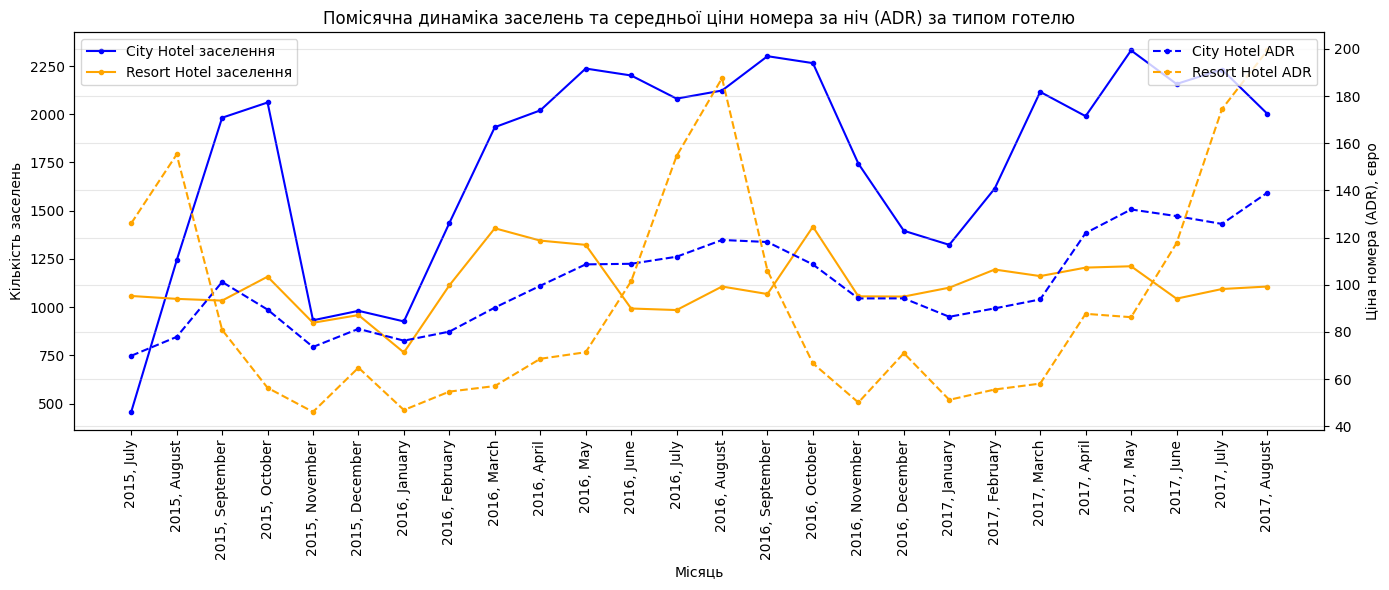

In [12]:
# Почнемо з візуалізації динаміки за допомогою лінійного графіка в Matplotlib за весь досліджуваний період щомісячних фактичних заселень
#  у готель та усередненого ADR. Таким чином ми можемо синхронно спостерігати зміни к-сті заселень та коливання ціни за номер для 2ох готелів
#  (суцільною лінією позначаємо заселення, штриховою - ADR; шкали для величин - справа і зліва відповідно).

# ! Для полегшення сприйняття тут і надалі я буду позначати дані для RESORT HOTEL (курортного готелю) ПОМАРАНЧЕВИМ, а для
#   CITY HOTEL (міського готелю) - СИНІМ !

import matplotlib.pyplot as plt

city_hotel_monthly_arrivals = monthly_arrivals_by_hotel_pivot['City Hotel']
resort_hotel_monthly_arrivals = monthly_arrivals_by_hotel_pivot['Resort Hotel']
city_hotel_monthly_mean_adr = monthly_mean_adr_by_hotel_pivot['City Hotel']
resort_hotel_monthly_mean_adr = monthly_mean_adr_by_hotel_pivot['Resort Hotel']

index_labels = [f"{year}, {month}" for year, month in monthly_arrivals_by_hotel_pivot.index]
x_pos = range(len(index_labels))

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_pos, city_hotel_monthly_arrivals, label='City Hotel заселення', color='blue', marker='.')
ax.plot(x_pos, resort_hotel_monthly_arrivals, label='Resort Hotel заселення', color='orange', marker='.')
ax.legend(loc='upper left')
ax.set_xlabel('Місяць')
ax.set_ylabel('Кількість заселень')
ax.set_xticks(x_pos)
ax.set_xticklabels(index_labels, rotation=90)

ax1 = ax.twinx()
ax1.plot(x_pos, city_hotel_monthly_mean_adr, label='City Hotel ADR', color='blue', linestyle='--', marker='.')
ax1.plot(x_pos, resort_hotel_monthly_mean_adr, label='Resort Hotel ADR', color='orange', linestyle='--', marker='.')
ax1.set_ylabel('Ціна номера (ADR), євро')
ax1.legend(loc='upper right')


plt.grid(True, alpha=0.3)
plt.title('Помісячна динаміка заселень та середньої ціни номера за ніч (ADR) за типом готелю', fontsize=12)
plt.tight_layout()
plt.show()


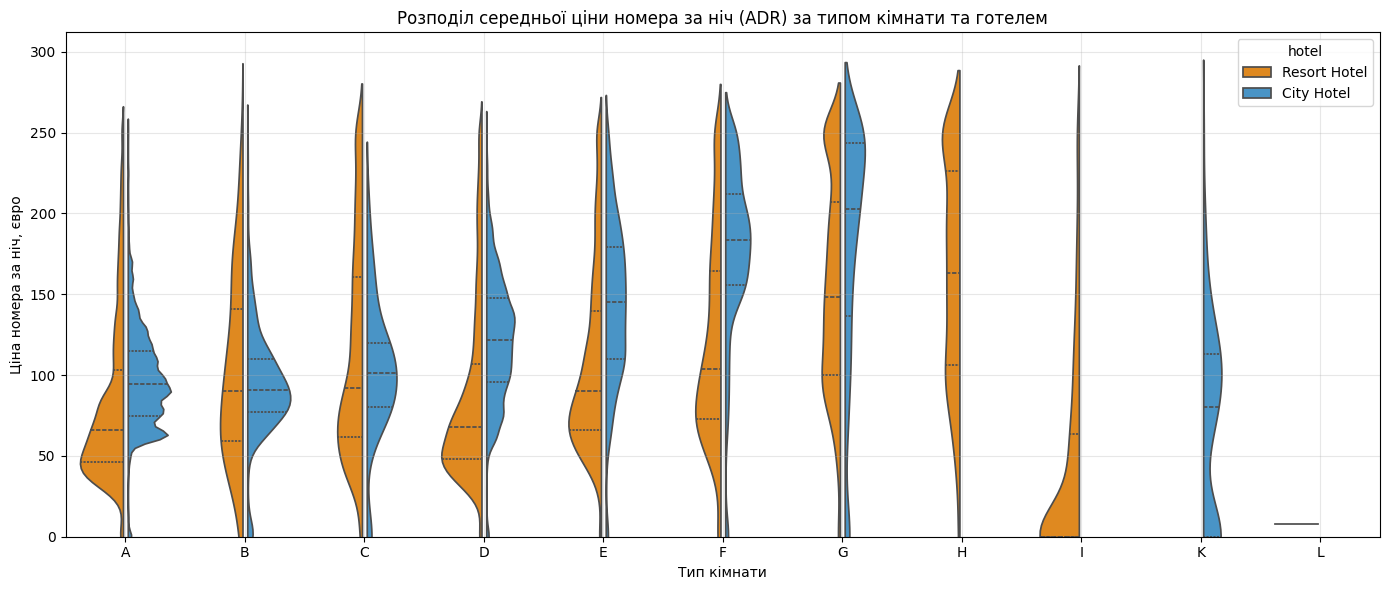

In [13]:
# З Seaborn візуалізуємо діапазони ADR за типом номерів для кожного готеля за допомогою violin plot.
#  Позначимо медіани та квартилі на розкидах диних.

import seaborn as sns

plt.figure(figsize=(14, 6))
sns.violinplot(df, x='assigned_room_type',
               y='average_daily_rate',
               order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L'],
               hue='hotel',
               split=True,
               gap=.1,
               inner="quart",
               palette=['#ff8c00', '#3498db']
               )
plt.xlabel('Тип кімнати')
plt.ylabel('Ціна номера за ніч, євро')
plt.title('Розподіл середньої ціни номера за ніч (ADR) за типом кімнати та готелем', fontsize=12)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

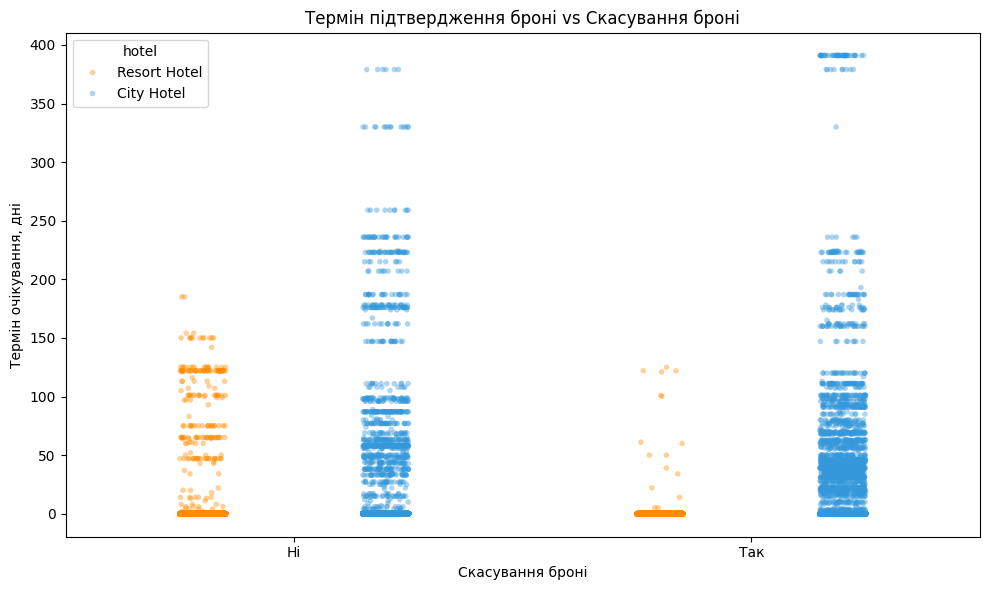

In [14]:
# Для наочної експрес-оцінки зв'язку в готелях між терміном очікування підтвердження резерву клієнту та скасуванням бронювань
#   побудувала точкову діаграму stripplot.

plt.figure(figsize=(10, 6))
sns.stripplot(df,
              x='is_canceled',
              y='days_in_waiting_list',
              hue='hotel',
              palette={'Resort Hotel': '#ff8c00', 'City Hotel': '#3498db'},
              size=4,
              alpha=0.4,
              dodge=True,
              jitter=True
              )
plt.xlabel('Скасування броні')
plt.ylabel('Термін очікування, дні')
plt.title('Термін підтвердження броні vs Скасування броні')
plt.xticks(['0', '1'], ['Ні', 'Так'])
plt.tight_layout()
plt.show()

In [15]:
# Використаю також і інтерактивну візуалізацію Plotly для аналізу к-сті заселень залежно від типу номера для кожного готеля.

import plotly.express as px

hotel_monthly_room_type = (df_actual_bookings.groupby(['arrival_date_year', 'arrival_date_month', 'hotel', 'assigned_room_type']).size().reset_index(name='count'))

hotel_monthly_room_type['period'] = (hotel_monthly_room_type['arrival_date_month'] + ',' + hotel_monthly_room_type['arrival_date_year'].astype(str))

fig = px.bar(hotel_monthly_room_type,
            x='period',
            y='count',
            color='assigned_room_type',
            facet_row='hotel',
            barmode='stack',
            labels={'count': 'Кількість заселень',
                    'period': 'Період',
                    'assigned_room_type': 'Тип номера'},
            color_discrete_sequence=px.colors.qualitative.Vivid,
            height=800,
            width=1200
)
fig.update_layout(title_text='Динаміка помісячної к-сті заселень за типом номера в готелі')
fig.show()

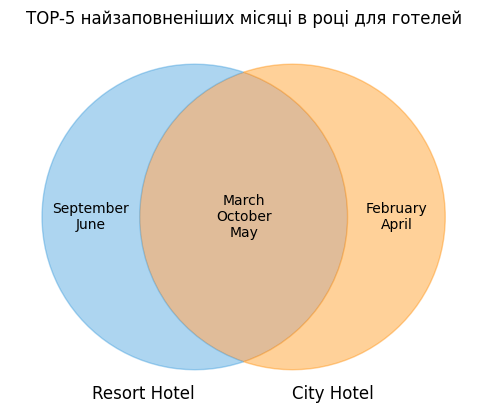

In [16]:
# Визначим спільні та відмінні найзаповненіші місяці для 2ох готелей за допомогою діаграми Венна,
#  побудованої з бібліотекою matplotlib-venn (дані взято з запита в BigQuery)

from matplotlib_venn import venn2

top5_city_hotel_months = {'May', 'June', 'October', 'September', 'March'}
top5_resort_hotel_months = {'October', 'March', 'April', 'May', 'February'}

v = venn2([top5_resort_hotel_months, top5_city_hotel_months,], set_labels=('Resort Hotel', 'City Hotel'))

only_city_hotel_top_months = top5_city_hotel_months - top5_resort_hotel_months
only_resort_hotel_top_months = top5_resort_hotel_months - top5_city_hotel_months
cross_months = top5_city_hotel_months & top5_resort_hotel_months

if v.get_label_by_id('10'):
    v.get_label_by_id('10').set_text("\n".join(list(only_city_hotel_top_months)))
if v.get_label_by_id('01'):
    v.get_label_by_id('01').set_text("\n".join(list(only_resort_hotel_top_months)))
if v.get_label_by_id('11'):
    v.get_label_by_id('11').set_text("\n".join(list(cross_months)))

if v.get_patch_by_id('10'):
    v.get_patch_by_id('10').set_color('#3498db')
if v.get_patch_by_id('01'):
    v.get_patch_by_id('01').set_color('#ff8c00')

plt.title('TOP-5 найзаповненіших місяці в році для готелей')
plt.show()
